In [1]:
import pandas as pd
import numpy as np
import random

random.seed(42)

# Load your cleaned dataset from Week 1
df = pd.read_csv("../data/processed/grievances_cleaned.csv")

# Define which complaints should be urgent

# Words that signal danger or emergency
urgent_keywords = [
    "live wire", "sparks", "sparking", "fallen", "burst",
    "dangerous", "burning", "accident", "cave", "crack",
    "contamination", "overflow", "sewage", "mixing"
]

# Words that indicate frustration/negativity
negative_keywords = [
    "not working", "no water", "no electricity", "not coming",
    "broken", "poor", "wrong", "overcharging", "complaint",
    "illegal", "blocked", "flooded", "encroached"
]

def assign_sentiment(text):

    text_lower = text.lower()

    # Check urgent keywords first (highest priority)
    for kw in urgent_keywords:
        if kw in text_lower:
            return "Urgent/Critical"

    # Then check negative keywords
    for kw in negative_keywords:
        if kw in text_lower:
            return "Negative"

    # Randomly assign remaining as Neutral or Negative
    return random.choice(["Neutral", "Negative"])


# Apply to every row using the ORIGINAL complaint text (not cleaned)
df["sentiment"] = df["complaint_text"].apply(assign_sentiment)

print("Sentiment distribution:")
print(df["sentiment"].value_counts())

print("\nSample rows:")
print(df[["complaint_text", "sentiment"]].head(8))

Sentiment distribution:
sentiment
Negative           50
Neutral            34
Urgent/Critical    16
Name: count, dtype: int64

Sample rows:
                     complaint_text        sentiment
0         Auto drivers overcharging         Negative
1      Bumpy road causing accidents  Urgent/Critical
2           Illegal dumping at park         Negative
3          Road flooded during rain         Negative
4  Speed breaker needed near school          Neutral
5     Wires sparking near residents  Urgent/Critical
6         Street lights not working         Negative
7            Bus not coming on time         Negative


In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os

# ── Inputs and target ──────────────────────────────────────

X = df["cleaned_text"]      # the cleaned complaint text
y = df["sentiment"]         # the sentiment label we just created

# ── Train/test split ───────────────────────────────────────

# 80% training, 20% testing. stratify=y ensures all
# sentiment classes appear in both train and test sets.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── TF-IDF Vectorization ───────────────────────────────────

# We create a NEW vectorizer specifically for sentiment.
# This is separate from the department vectorizer.

sent_vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2)
)

X_train_tfidf = sent_vectorizer.fit_transform(X_train)
X_test_tfidf = sent_vectorizer.transform(X_test)

# ── Train the model ────────────────────────────────────────

sent_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # handles class imbalance automatically
    random_state=42
)

sent_model.fit(X_train_tfidf, y_train)

print("Sentiment model trained!")

# ── Cross-Validation ───────────────────────────────────────

cv = cross_val_score(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    sent_vectorizer.transform(X),
    y,
    cv=5
)

print(
    f"\n5-Fold CV Accuracy: {cv.mean():.3f} ± {cv.std():.3f}"
)

# ── Predictions ────────────────────────────────────────────

y_pred = sent_model.predict(X_test_tfidf)

# ── Metrics ────────────────────────────────────────────────

print("\n=== SENTIMENT MODEL EVALUATION ===")

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro F1 : {f1_score(y_test, y_pred, average='macro'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Train: 80 | Test: 20
Sentiment model trained!

5-Fold CV Accuracy: 0.590 ± 0.049

=== SENTIMENT MODEL EVALUATION ===
Accuracy : 0.7500
Macro F1 : 0.7116

Classification Report:
                 precision    recall  f1-score   support

       Negative       0.71      1.00      0.83        10
        Neutral       1.00      0.29      0.44         7
Urgent/Critical       0.75      1.00      0.86         3

       accuracy                           0.75        20
      macro avg       0.82      0.76      0.71        20
   weighted avg       0.82      0.75      0.70        20



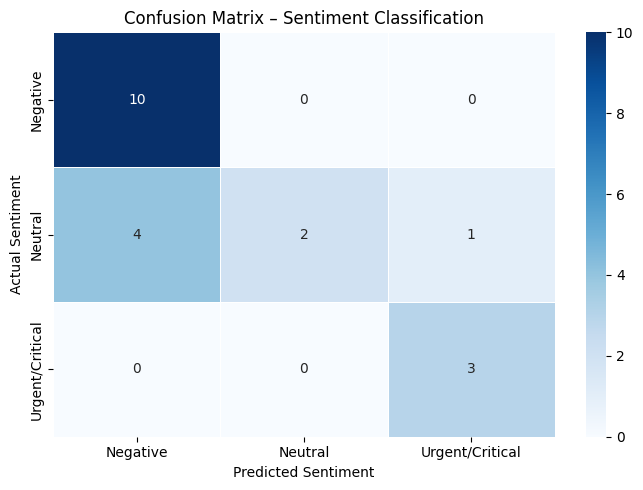

Confusion matrix saved!


In [3]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Confusion Matrix 

labels = ["Negative", "Neutral", "Urgent/Critical"]

cm_matrix = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_matrix,
    annot=True,          # show numbers inside each cell
    fmt="d",             # format as integers
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5
)

plt.title("Confusion Matrix – Sentiment Classification")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()

# Save the chart as an image file
os.makedirs("../data/processed", exist_ok=True)

plt.savefig("../data/processed/sentiment_confusion_matrix.png")

plt.show()

print("Confusion matrix saved!")

In [4]:
# Priority score map — higher number = more urgent

PRIORITY_MAP = {
    "Positive": 1,
    "Neutral": 2,
    "Negative": 3,
    "Urgent/Critical": 4
}

def calculate_priority_score(sentiment_label, model_confidence):
    """
    Returns a score between 0.0 and 1.0.

    Formula: base_weight * confidence

    Urgent/Critical at 90% confidence = 4 * 0.90 / 4 = 0.90
    Negative at 70% confidence = 3 * 0.70 / 4 = 0.525
    """

    base = PRIORITY_MAP.get(sentiment_label, 1)
    max_base = 4  # highest possible base score

    score = (base / max_base) * model_confidence

    return round(score, 4)


# Test the scoring function with examples

examples = [
    ("Urgent/Critical", 0.92),
    ("Urgent/Critical", 0.65),
    ("Negative", 0.88),
    ("Neutral", 0.75),
    ("Positive", 0.90),
]

print("Priority Score Examples:")

print(f"{'Sentiment':<20} {'Confidence':<12} {'Priority Score'}")
print("-" * 50)

for sent, conf in examples:
    score = calculate_priority_score(sent, conf)
    print(f"{sent:<20} {conf:<12} {score}")

# Apply to the full dataset to see real scores

proba = sent_model.predict_proba(
    sent_vectorizer.transform(X)
)

confidences = proba.max(axis=1)  # highest probability for each row

df["priority_score"] = [
    calculate_priority_score(sent, conf)
    for sent, conf in zip(df["sentiment"], confidences)
]

print("\nTop 5 highest priority complaints:")

top5 = df.sort_values(
    "priority_score",
    ascending=False
).head(5)

print(
    top5[
        ["complaint_text", "sentiment", "priority_score"]
    ]
)

Priority Score Examples:
Sentiment            Confidence   Priority Score
--------------------------------------------------
Urgent/Critical      0.92         0.92
Urgent/Critical      0.65         0.65
Negative             0.88         0.66
Neutral              0.75         0.375
Positive             0.9          0.225

Top 5 highest priority complaints:
                       complaint_text        sentiment  priority_score
36        Sewage overflow near houses  Urgent/Critical          0.6219
5       Wires sparking near residents  Urgent/Critical          0.6209
68    Dustbin overflowing near market  Urgent/Critical          0.6183
96                Manhole overflowing  Urgent/Critical          0.5967
35  Sewage mixing with drinking water  Urgent/Critical          0.5951


In [ ]:
# Save the sentiment model AND its vectorizer

# Both are needed: vectorizer converts text → numbers
# Model uses those numbers to predict sentiment

os.makedirs("../src", exist_ok=True)

# Save the trained sentiment classifier
with open("../src/sentiment_model.pkl", "wb") as f:
    pickle.dump(sent_model, f)

# Save the TF-IDF vectorizer for sentiment
with open("../src/sentiment_vectorizer.pkl", "wb") as f:
    pickle.dump(sent_vectorizer, f)

# Quick verification: reload and test it works
with open("../src/sentiment_model.pkl", "rb") as f:
    test_load = pickle.load(f)

test_text = ["live wire sparking near school very dangerous"]

test_vec = sent_vectorizer.transform(test_text)

test_pred = test_load.predict(test_vec)[0]
test_prob = test_load.predict_proba(test_vec).max()

print(f"Test prediction: {test_pred}")
print(f"Confidence     : {test_prob:.4f}")

print("\nFiles saved:")

print("  src/sentiment_model.pkl")
print("  src/sentiment_vectorizer.pkl")  

Test prediction: Urgent/Critical
Confidence     : 0.6117

Files saved:
  src/sentiment_model.pkl
  src/sentiment_vectorizer.pkl
